# Aplicação Estratégica — do modelo à decisão de política pública

**Tech Challenge Fase 3 — POSTECH AI Scientist**

Os notebooks anteriores construíram o dado ([01](01_pipeline_medalhao.ipynb)), entenderam o
problema ([02](02_analise_exploratoria.ipynb)) e ajustaram o modelo
([03](03_modelagem.ipynb)). Este responde às **cinco perguntas de negócio** do enunciado, para
uma audiência de gestor público — não de cientista de dados.

| Pergunta do enunciado | Seção |
|---|---|
| Quais fatores mais impactam a alfabetização? | §1 |
| Quais variáveis possuem maior influência nos modelos? | §1 |
| Quais municípios apresentam maior risco educacional? | §2 |
| Quais regiões possuem padrões semelhantes? | §3 |
| Como prever municípios que podem não atingir metas futuras? | §4 |

E fecha com uma matriz de priorização (§5) e com os limites do que estas análises autorizam a
afirmar (§6).

> **Advertência que vale para o notebook inteiro.** Nada aqui é um experimento. O modelo mede
> **associações condicionais**, não efeitos causais. "Municípios com mais docentes licenciados
> na área alfabetizam mais" não é o mesmo que "contratar docentes licenciados fará a taxa subir".
> As recomendações abaixo são hipóteses de intervenção priorizadas por evidência — não provas.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from src.preprocessing import carregar_base_ml, ler_particionado
from src.preprocessing.config import LAKE_DIR
from src.modeling import construir_pipeline, expandir_binomial
from src.modeling import features as F
from src.evaluation import (
    avaliar_k, efeitos_marginais, estabilidade_ranking, preparar_segmentacao,
    segmentar, tabela_municipal,
)
from src.visualization import (
    EIXO, GRADE, MUDO, NEGATIVO, POSITIVO, SERIE, TINTA, TINTA_2,
    aplicar_estilo, limpar, num, salvar,
)

warnings.filterwarnings("ignore")
pd.set_option("display.width", 175)
pd.set_option("display.max_columns", 60)
aplicar_estilo()

IMAGENS = RAIZ / "images"
IMAGENS.mkdir(exist_ok=True)
SEMENTE = 42

# Reajusta o modelo final do notebook 03.
base = carregar_base_ml().drop(columns=["_gold_processed_at"])
X, y, peso, grupos = expandir_binomial(base)
modelo = construir_pipeline(C=1.0)
modelo.fit(X, y, modelo__sample_weight=peso)

municipios = tabela_municipal(modelo, base)
print(f"{len(municipios)} linhas município × ano | "
      f"{municipios['id_municipio'].nunique()} municípios | "
      f"taxa esperada média {municipios['taxa_esperada'].mean():.1f}%")

10896 linhas município × ano | 5500 municípios | taxa esperada média 61.5%


---

## 1. Quais fatores mais impactam a alfabetização?

O notebook 03 respondeu isso em *odds ratio*, que é a forma estatisticamente correta. Para uma
reunião executiva, a unidade útil é outra: **quantos pontos percentuais** a taxa esperada se
move quando a variável melhora em um desvio-padrão.

In [2]:
efeitos = efeitos_marginais(modelo, base, F.NUMERICAS_GERAIS + F.NUMERICAS_IDEB)

# Separação que muda a conversa: o que um gestor municipal consegue mudar,
# e o que ele recebe como condição dada.
ACIONAVEIS = set(F.AFD + F.ATU + F.IED)
efeitos["natureza"] = np.where(efeitos.index.isin(ACIONAVEIS),
                               "alavanca escolar", "condição estrutural")
efeitos.head(10).round(2)

,efeito_pp,natureza
variavel,,
ideb_2021,5.52,condição estrutural
media_inse,2.54,condição estrutural
atu_anos_iniciais,-1.46,alavanca escolar
afd_ai_grupo_1,1.31,alavanca escolar
atu_2_ano,-1.21,alavanca escolar
afd_ai_grupo_3,0.90,alavanca escolar
ied_ai_nivel_4,-0.77,alavanca escolar
qtd_alunos_inse,-0.76,condição estrutural
atu_creche,0.59,alavanca escolar


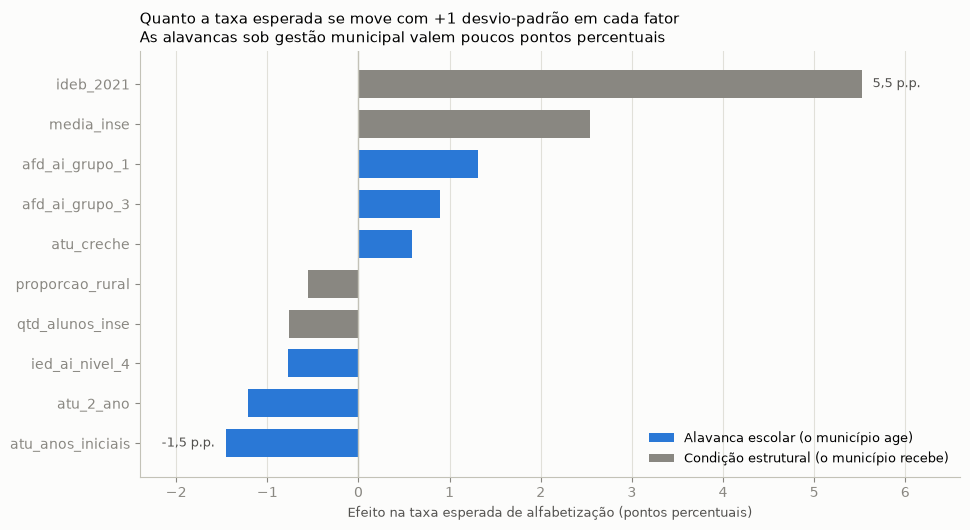

In [3]:
principais = efeitos.head(10).sort_values("efeito_pp")
cores = [SERIE[0] if n == "alavanca escolar" else MUDO for n in principais["natureza"]]

fig, eixo = plt.subplots(figsize=(9.8, 5.4))
eixo.barh(principais.index, principais["efeito_pp"], color=cores, height=0.7)
eixo.axvline(0, color=EIXO, linewidth=1)

for nome in (principais.index[0], principais.index[-1]):
    valor = principais.loc[nome, "efeito_pp"]
    eixo.text(valor + (0.12 if valor > 0 else -0.12), nome, f"{num(valor, 1)} p.p.",
              va="center", ha="left" if valor > 0 else "right", fontsize=9, color=TINTA_2)

from matplotlib.patches import Patch
eixo.legend(handles=[Patch(facecolor=SERIE[0], label="Alavanca escolar (o município age)"),
                     Patch(facecolor=MUDO, label="Condição estrutural (o município recebe)")],
            loc="lower right", fontsize=9)

eixo.set_title("Quanto a taxa esperada se move com +1 desvio-padrão em cada fator\n"
               "As alavancas sob gestão municipal valem poucos pontos percentuais", loc="left")
eixo.set_xlabel("Efeito na taxa esperada de alfabetização (pontos percentuais)")
eixo.set_xlim(-2.4, 6.6)
limpar(eixo, grade="x")
fig.tight_layout()
salvar(fig, "04_efeitos_marginais", IMAGENS)
plt.show()

> **Como ler as barras negativas.** `atu_anos_iniciais` e `atu_2_ano` aparecem em azul
> (alavanca escolar) com efeito negativo: turmas **maiores** reduzem a taxa esperada. A alavanca,
> portanto, é **diminuir** o número de alunos por turma. A cor identifica a natureza do fator —
> quem age sobre ele —, não o sinal do efeito, que o eixo carrega.

### A resposta, em três camadas

**1ª camada — a política estadual, e ela é a maior de todas.** Não aparece neste gráfico porque
não é uma variável contínua, mas o notebook 03 mediu: a dummy do Ceará tem *odds ratio* **5,06**
depois de controlar tudo o mais, e embaralhar `sigla_uf` derruba o AUC em 0,080 — quase o dobro
do IDEB e dez vezes o nível socioeconômico. **A unidade federativa é o fator mais importante do
modelo.**

**2ª camada — o desempenho pregresso do município.** Um desvio-padrão a mais no IDEB de 2021 vale
**+5,5 p.p.** na taxa esperada. É o maior efeito contínuo, e é também o mais difícil de mover no
curto prazo: mede o acúmulo da rede.

**3ª camada — condição socioeconômica e alavancas escolares.** O INSE vale **+2,5 p.p.** por
desvio-padrão. As variáveis que um gestor municipal efetivamente controla — formação docente e
tamanho de turma — valem, cada uma, **entre 1 e 1,5 p.p.**

### O que isso significa para a decisão

Duas leituras opostas cabem no mesmo número, e as duas são verdadeiras:

- **Desanimadora:** as alavancas municipais são pequenas. Melhorar a formação docente em um
  desvio-padrão inteiro — algo que leva anos — rende ~1,3 p.p.
- **Encorajadora:** a maior fonte de variação não é a renda das famílias, é a **política
  pública**. O Ceará tem INSE igual ao de Pernambuco e uma taxa 27 pontos maior. Se o resultado
  fosse determinado pela condição socioeconômica, não haveria o que recomendar a um gestor.

A conclusão prática é que **o ganho de escala está na política estadual e na difusão de práticas
entre redes**, não no ajuste marginal de indicadores escolares município a município.

---

## 2. Quais municípios apresentam maior risco educacional?

"Risco" precisa de definição operacional, e há duas candidatas que não são a mesma coisa:

- **Risco de nível** — o município alfabetiza pouco, em termos absolutos;
- **Risco relativo** — o município alfabetiza **menos do que a estrutura dele permitiria**.

A segunda é a mais sedutora: ela isola o que não se explica por contexto e parece apontar
diretamente para a qualidade da gestão. O modelo permite calculá-la — é o **resíduo**
(taxa observada − taxa esperada). Mas antes de usá-la para produzir uma lista, ela precisa passar
por um teste.

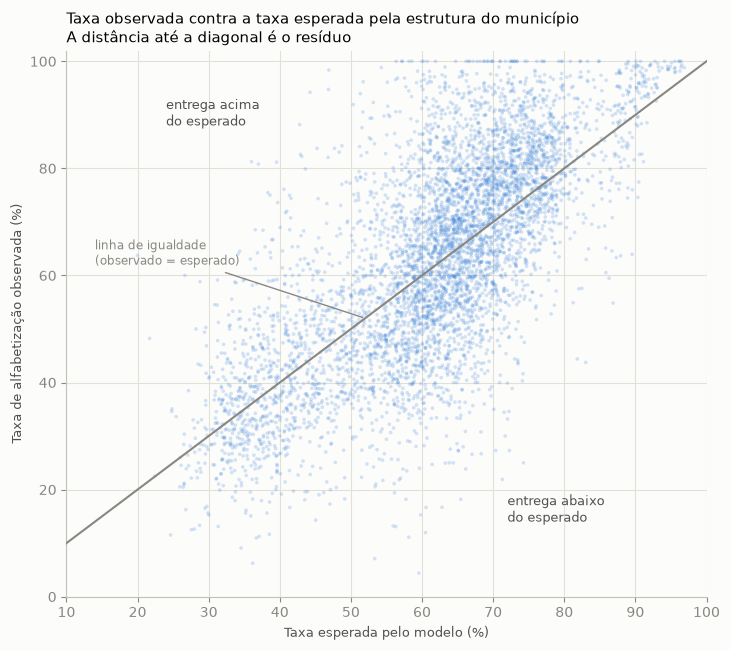

In [4]:
fig, eixo = plt.subplots(figsize=(7.4, 6.6))

de_2024 = municipios[municipios["ano"] == 2024]
eixo.scatter(de_2024["taxa_esperada"], de_2024["taxa_alfabetizacao"],
             s=7, alpha=0.2, color=SERIE[0], edgecolors="none", label="Municípios (2024)")
eixo.plot([0, 100], [0, 100], color=MUDO, linewidth=1.5, zorder=3)

eixo.annotate("entrega acima\ndo esperado", xy=(24, 88), fontsize=9, color=TINTA_2)
eixo.annotate("entrega abaixo\ndo esperado", xy=(72, 14), fontsize=9, color=TINTA_2)
eixo.annotate("linha de igualdade\n(observado = esperado)", xy=(52, 52), xytext=(14, 62),
              fontsize=8.5, color=MUDO,
              arrowprops=dict(arrowstyle="-", color=MUDO, linewidth=1))

eixo.set_title("Taxa observada contra a taxa esperada pela estrutura do município\n"
               "A distância até a diagonal é o resíduo", loc="left")
eixo.set_xlabel("Taxa esperada pelo modelo (%)")
eixo.set_ylabel("Taxa de alfabetização observada (%)")
eixo.set_xlim(10, 100)
eixo.set_ylim(0, 102)
limpar(eixo)
eixo.grid(axis="x", color=GRADE, linewidth=0.8)
fig.tight_layout()
salvar(fig, "04_observado_esperado", IMAGENS)
plt.show()

### O teste que a lista de risco relativo precisa passar

Uma lista de prioridade só serve se for **estável**: se os "300 piores" de um ciclo forem outros
300 no ciclo seguinte, o critério está medindo ruído, não problema. Vamos verificar.

In [5]:
estabilidade_residuo = estabilidade_ranking(municipios, "residuo")
estabilidade_nivel = estabilidade_ranking(municipios, "taxa_alfabetizacao")

comparacao = estabilidade_residuo.merge(
    estabilidade_nivel, on="tamanho_da_lista", suffixes=("_resíduo", "_taxa observada"))

print(f"Correlação do resíduo entre 2023 e 2024: "
      f"{estabilidade_residuo.attrs['correlacao_entre_ciclos']}")
print(f"Correlação da taxa observada entre 2023 e 2024: "
      f"{estabilidade_nivel.attrs['correlacao_entre_ciclos']}")
comparacao[["tamanho_da_lista", "sobreposição_%_resíduo", "sobreposição_%_taxa observada"]]

Correlação do resíduo entre 2023 e 2024: 0.283
Correlação da taxa observada entre 2023 e 2024: 0.636


,tamanho_da_lista,sobreposição_%_resíduo,sobreposição_%_taxa observada
0,300,17.3,35.7
1,500,19.6,48.4
2,1000,31.6,59.4


### O resultado reprova o uso ingênuo do resíduo

A lista dos **300 municípios com pior resíduo em 2023 tem apenas 17% de coincidência** com a
mesma lista feita em 2024. A correlação do resíduo entre os dois ciclos é de **0,28**.

Publicar essa lista como "os municípios que pior gerem sua rede" seria **irresponsável**: quatro
em cada cinco nomes mudariam no ciclo seguinte. O resíduo de um único ciclo mistura três coisas
que não conseguimos separar — gestão, variação amostral da avaliação e mudanças reais que o
modelo não observa (ele não tem `ano` nem variáveis de política).

A taxa observada é bem mais estável (correlação 0,64; 36% de coincidência na lista de 300) — e é,
não por acaso, o que a política pública já usa como critério.

### O resíduo *é* útil — em outro nível de agregação

O que não funciona município a município funciona bem no agregado, onde o ruído individual se
cancela. E aqui o resíduo faz algo notável: **ele detecta o choque do Rio Grande do Sul sozinho**.

In [6]:
por_uf = municipios.pivot_table(index="sigla_uf", columns="ano", values="residuo").round(2)
por_uf["variação"] = (por_uf[2024] - por_uf[2023]).round(2)
por_uf.dropna().sort_values("variação").head(5)

ano,2023,2024,variação
sigla_uf,,,
RS,10.07,-10.27,-20.34
PR,0.89,-0.76,-1.65
AM,0.62,-0.77,-1.39
BA,0.43,-0.58,-1.01
CE,0.43,0.74,0.31


O Rio Grande do Sul sai de **+10,1** em 2023 (entregando acima do esperado) para **−10,3** em 2024
— uma inversão de 20 pontos, isolada de qualquer outra UF. O modelo não conhece enchentes; ele
apenas registra que o estado passou a entregar muito abaixo do que sua estrutura previa. Isso
valida o resíduo como **instrumento de alerta agregado**: ele não diz *o que* aconteceu, mas
aponta com precisão *onde* investigar.

### Recomendação operacional

| Uso | Recomendado? | Por quê |
|---|---|---|
| Priorizar por **taxa observada** | **Sim** | estável entre ciclos e diretamente ligado ao objetivo da política |
| Ranquear municípios pelo **resíduo de um ciclo** | **Não** | 17% de estabilidade; produziria uma lista quase aleatória |
| Monitorar **resíduo agregado** por UF ou segmento | **Sim** | o ruído individual se cancela; detecta choques como o do RS |
| Usar o resíduo como **triagem** para investigação | Com ressalva | serve para escolher onde olhar, nunca como veredito sobre um gestor |

In [7]:
# Como fica o retrato de risco quando as duas dimensões são cruzadas
recorte = municipios[municipios["ano"] == 2024].copy()
recorte["nível"] = np.where(
    recorte["taxa_alfabetizacao"] < recorte["taxa_alfabetizacao"].quantile(0.25),
    "taxa no quartil inferior", "demais")
recorte["estrutura"] = np.where(
    recorte["residuo"] < recorte["residuo"].quantile(0.25),
    "abaixo do esperado", "no esperado ou acima")

pd.crosstab(recorte["nível"], recorte["estrutura"], margins=True, margins_name="total")

estrutura,abaixo do esperado,no esperado ou acima,total
nível,,,
demais,562,3525,4087
taxa no quartil inferior,800,561,1361
total,1362,4086,5448


O cruzamento mostra por que as duas leituras não são intercambiáveis. Dos municípios no quartil
de menor taxa, pouco mais da metade também está abaixo do que sua estrutura previa. Os demais
**alfabetizam pouco, mas dentro do que o contexto explica** — e para esses a resposta de política
é outra: não adianta cobrar gestão, é preciso mudar a condição (formação docente, porte de turma,
infraestrutura).

---

## 3. Quais regiões possuem padrões semelhantes?

A pergunta pede agrupar municípios por **perfil**, não por localização. Usamos K-means sobre o
perfil estrutural (socioeconômico, docente, de turma e desempenho pregresso), deliberadamente
**sem incluir a UF** — se a incluíssemos, os grupos reproduziriam o mapa e a resposta seria
circular.

Primeiro, quantos grupos existem de fato?

In [8]:
perfil = municipios[municipios["ano"] == 2024].reset_index(drop=True)
colunas_perfil = F.NUMERICAS_GERAIS + F.NUMERICAS_IDEB
matriz = preparar_segmentacao(perfil, colunas_perfil)

diagnostico_k = avaliar_k(matriz, range(2, 9))
diagnostico_k.round(4)

,k,inercia,silhueta,menor_grupo
0,2,114245.5208,0.1959,2545
1,3,106836.1044,0.1303,1562
2,4,101250.7888,0.1170,1048
3,5,97178.3297,0.0934,762
4,6,93795.9822,0.0935,4
5,7,91259.0262,0.0956,4
6,8,88858.9180,0.0983,4


**A silhueta não passa de 0,20 em nenhum valor de `k`.** Isso é uma resposta em si: **não existem
grupos naturais de municípios brasileiros neste espaço de características**. Os perfis formam um
**contínuo**, não ilhas separadas.

Seguimos com `k = 4` — não como uma estrutura descoberta nos dados, mas como uma **partição de
conveniência para comunicação**, que produz grupos de tamanho equilibrado e interpretáveis. É uma
distinção que precisa ficar explícita: chamar isso de "quatro tipos de município" seria
sobrevender o resultado.

In [9]:
perfil["segmento"] = segmentar(matriz, k=4)

DESTAQUE = ["media_inse", "proporcao_rural", "qtd_alunos_inse", "ideb_2021",
            "afd_ai_grupo_1", "atu_anos_iniciais", "taxa_alfabetizacao"]

resumo_segmentos = perfil.groupby("segmento")[DESTAQUE].mean().round(2)
resumo_segmentos.insert(0, "municípios", perfil["segmento"].value_counts().sort_index())
resumo_segmentos

,municípios,media_inse,proporcao_rural,qtd_alunos_inse,ideb_2021,afd_ai_grupo_1,atu_anos_iniciais,taxa_alfabetizacao
segmento,,,,,,,,
0,1973,4.36,0.27,515.54,4.92,64.23,18.99,54.77
1,1048,5.44,0.12,240.16,6.22,83.75,17.89,66.69
2,1067,4.93,0.17,133.48,5.65,77.44,15.45,68.27
3,1360,5.10,0.07,861.89,5.83,83.32,21.58,67.15


In [10]:
composicao = (pd.crosstab(perfil["segmento"], perfil["regiao"], normalize="index") * 100)
composicao = composicao.round(0).astype(int)
composicao["UFs presentes"] = perfil.groupby("segmento")["sigla_uf"].nunique()
composicao

regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul,UFs presentes
segmento,,,,,,
0,1,80,15,4,0,24
1,2,0,0,31,67,10
2,11,12,5,52,20,23
3,23,5,7,49,16,24


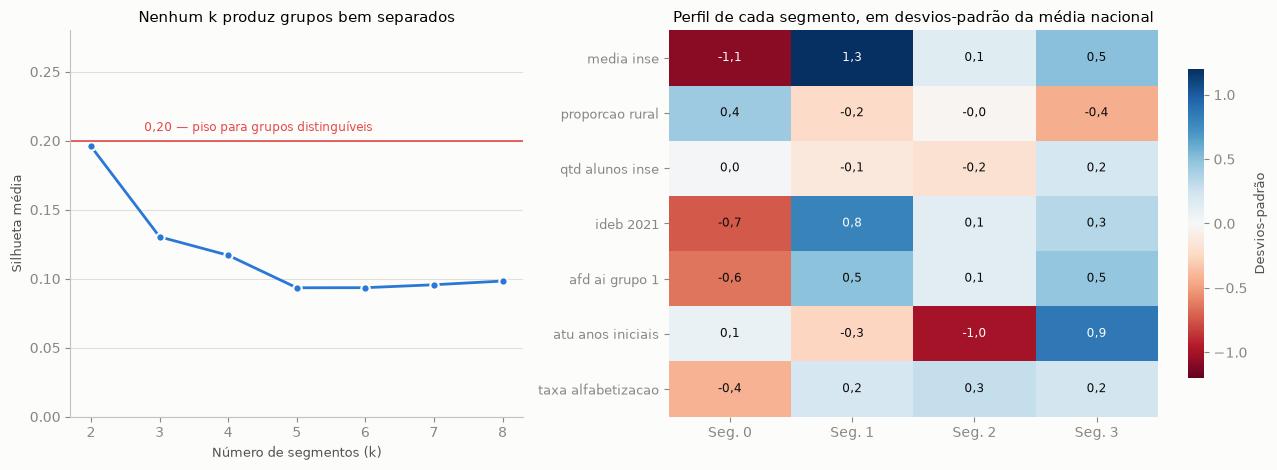

In [11]:
# Perfil dos segmentos em desvios-padrão da média nacional (leitura comparativa)
padronizado = ((perfil.groupby("segmento")[DESTAQUE].mean() - perfil[DESTAQUE].mean())
               / perfil[DESTAQUE].std())

fig, eixos = plt.subplots(1, 2, figsize=(13, 4.8),
                          gridspec_kw={"width_ratios": [1, 1.35]})

# --- Painel A: não há k natural ---
eixos[0].plot(diagnostico_k["k"], diagnostico_k["silhueta"], color=SERIE[0], linewidth=2,
              marker="o", markersize=6, markerfacecolor=SERIE[0],
              markeredgecolor="#fcfcfb", markeredgewidth=1.5)
eixos[0].axhline(0.2, color=NEGATIVO, linewidth=1.2)
eixos[0].text(6.1, 0.207, "0,20 — piso para grupos distinguíveis",
              fontsize=8.5, color=NEGATIVO, ha="right")
eixos[0].set_title("Nenhum k produz grupos bem separados")
eixos[0].set_xlabel("Número de segmentos (k)")
eixos[0].set_ylabel("Silhueta média")
eixos[0].set_ylim(0, 0.28)
limpar(eixos[0])

# --- Painel B: perfil dos 4 segmentos (divergente: acima/abaixo da média) ---
imagem = eixos[1].imshow(padronizado.T, cmap="RdBu", vmin=-1.2, vmax=1.2, aspect="auto")
eixos[1].set_xticks(range(4), [f"Seg. {i}" for i in range(4)])
eixos[1].set_yticks(range(len(DESTAQUE)), [c.replace("_", " ") for c in DESTAQUE], fontsize=9)
for i in range(len(DESTAQUE)):
    for j in range(4):
        valor = padronizado.T.iloc[i, j]
        eixos[1].text(j, i, num(valor, 1), ha="center", va="center", fontsize=8.5,
                      color="#fcfcfb" if abs(valor) > 0.75 else TINTA)
eixos[1].set_title("Perfil de cada segmento, em desvios-padrão da média nacional")
eixos[1].grid(False)
eixos[1].spines[:].set_visible(False)
barra = fig.colorbar(imagem, ax=eixos[1], shrink=0.8)
barra.outline.set_visible(False)
barra.set_label("Desvios-padrão", fontsize=9, color=TINTA_2)

fig.tight_layout()
salvar(fig, "04_segmentos", IMAGENS)
plt.show()

### Os quatro segmentos

| Segmento | Perfil | Taxa média | Onde está |
|---|---|---:|---|
| **0 — Vulnerabilidade concentrada** | menor INSE, mais rural, menor IDEB pregresso, menor qualificação docente | **54,8%** | 80% Nordeste, 15% Norte — mas presente em **24 UFs** |
| **1 — Redes pequenas consolidadas** | maior INSE, docentes mais qualificados, alto esforço docente | 66,7% | 67% Sul, 31% Sudeste |
| **2 — Municípios muito pequenos** | menor porte, turmas pequenas, INSE intermediário | **68,3%** | 52% Sudeste, 20% Sul |
| **3 — Redes de maior porte** | maior número de alunos, turmas grandes, INSE acima da média | 67,2% | 49% Sudeste, 23% Centro-Oeste |

### A resposta à pergunta — e ela contraria a formulação

O enunciado pergunta quais **regiões** têm padrões semelhantes. O dado responde outra coisa:
**os padrões não respeitam as regiões**.

- O segmento de maior vulnerabilidade está presente em **24 das 25 UFs** da base — não é um
  fenômeno "do Nordeste", é um fenômeno de perfil que aparece no interior de todas as regiões;
- **cada região contém 3 ou 4 dos 4 segmentos**;
- e as duas primeiras componentes principais explicam apenas 38,6% da variância — mais uma
  evidência de contínuo, não de tipos discretos.

**Consequência para a política pública:** um programa desenhado por região erraria o alvo.
Municípios do interior de Minas Gerais, do sertão da Bahia e do interior do Pará podem compartilhar
o mesmo perfil de vulnerabilidade e responder ao mesmo desenho de intervenção — enquanto capitais
do Nordeste e do Sul se parecem mais entre si do que com seus próprios vizinhos. **A focalização
eficiente é por perfil, não por território.**

---

## 4. Como prever municípios que podem não atingir metas futuras?

O Compromisso Nacional Criança Alfabetizada pactuou metas por município. Elas estão na camada
Gold herdada da Fase 2 e chegam aqui **apenas como referência de comparação** — nunca entraram no
modelo como preditor, justamente porque são calculadas a partir da taxa de 2023 (é o vazamento
mapeado no notebook 01).

> **Ressalva metodológica que precisa acompanhar qualquer número desta seção.** Como a meta de
> cada município é derivada do seu próprio resultado de 2023, "não atingir a meta" significa "não
> manter a trajetória pactuada a partir do próprio ponto de partida" — e não "estar abaixo de um
> padrão nacional". Municípios que partiram de patamares muito baixos têm metas muito baixas.

In [12]:
gold_f2 = ler_particionado(LAKE_DIR / "gold" / "alfabetizacao_por_municipio")
metas = gold_f2[gold_f2["ano"] == 2024][["id_municipio", "meta_2025"]]

situacao = (municipios[municipios["ano"] == 2024]
            .merge(metas, on="id_municipio", how="left")
            .dropna(subset=["meta_2025"]))
situacao["gap_observado"] = situacao["taxa_alfabetizacao"] - situacao["meta_2025"]
situacao["gap_estrutural"] = situacao["taxa_esperada"] - situacao["meta_2025"]

pd.Series({
    "municípios com meta pactuada": len(situacao),
    "já atingiram a meta 2025 (dado de 2024)": int((situacao["gap_observado"] >= 0).sum()),
    "ainda abaixo da meta 2025": int((situacao["gap_observado"] < 0).sum()),
    "distância mediana até a meta, entre os que faltam (p.p.)":
        round(situacao.loc[situacao["gap_observado"] < 0, "gap_observado"].median(), 1),
    "abaixo da meta E com estrutura que não a sustenta":
        int(((situacao["gap_observado"] < 0) & (situacao["gap_estrutural"] < 0)).sum()),
}).to_frame("situação em 2024")

,situação em 2024
municípios com meta pactuada,5352.0
já atingiram a meta 2025 (dado de 2024),2322.0
ainda abaixo da meta 2025,3030.0
"distância mediana até a meta, entre os que faltam (p.p.)",-9.9
abaixo da meta E com estrutura que não a sustenta,2352.0


**43% dos municípios já cumpriram, em 2024, a meta pactuada para 2025.** Restam **3.030 abaixo**,
com distância mediana de **9,9 pontos percentuais**.

O modelo acrescenta uma distinção que a simples comparação com a meta não faz: entre os que estão
abaixo, quais têm uma **estrutura compatível** com a meta (e portanto podem alcançá-la com
melhoria de gestão) e quais têm uma estrutura que, mantida como está, **não sustenta a meta** —
para esses, cobrar resultado sem alterar as condições é cobrar o impossível.

In [13]:
def classificar(linha):
    if linha["gap_observado"] >= 0:
        return "1. Meta já atingida"
    if linha["gap_estrutural"] >= 0:
        return "2. Abaixo da meta, mas a estrutura a sustenta"
    return "3. Abaixo da meta e a estrutura não a sustenta"

situacao["situacao"] = situacao.apply(classificar, axis=1)

quadro = (situacao.groupby("situacao")
          .agg(municípios=("id_municipio", "size"),
               taxa_media=("taxa_alfabetizacao", "mean"),
               distancia_mediana_pp=("gap_observado", "median"))
          .round(1))
quadro["% do total"] = (quadro["municípios"] / len(situacao) * 100).round(1)
quadro

,municípios,taxa_media,distancia_mediana_pp,% do total
situacao,,,,
1. Meta já atingida,2322,77.7,9.2,43.4
"2. Abaixo da meta, mas a estrutura a sustenta",678,50.2,-6.8,12.7
3. Abaixo da meta e a estrutura não a sustenta,2352,52.3,-11.5,43.9


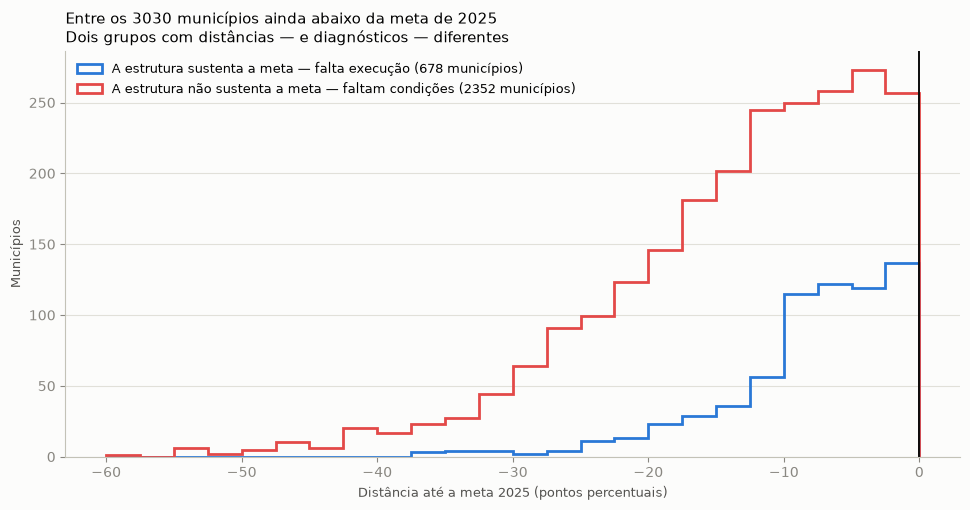

In [14]:
fig, eixo = plt.subplots(figsize=(9.8, 5.2))

# Só os municípios que ainda não atingiram a meta — é essa a população da decisão.
abaixo_da_meta = situacao[situacao["gap_observado"] < 0]
faixas = np.arange(-60, 2.5, 2.5)

for cor, (rotulo, dados) in zip(
    [SERIE[0], NEGATIVO],
    [("A estrutura sustenta a meta — falta execução",
      abaixo_da_meta.loc[abaixo_da_meta["gap_estrutural"] >= 0, "gap_observado"]),
     ("A estrutura não sustenta a meta — faltam condições",
      abaixo_da_meta.loc[abaixo_da_meta["gap_estrutural"] < 0, "gap_observado"])],
):
    eixo.hist(dados, bins=faixas, histtype="step", linewidth=2, color=cor,
              label=f"{rotulo} ({len(dados)} municípios)")

eixo.axvline(0, color=TINTA, linewidth=1.4)

eixo.set_title(f"Entre os {len(abaixo_da_meta)} municípios ainda abaixo da meta de 2025\n"
               "Dois grupos com distâncias — e diagnósticos — diferentes", loc="left")
eixo.set_xlabel("Distância até a meta 2025 (pontos percentuais)")
eixo.set_ylabel("Municípios")
eixo.legend(loc="upper left", fontsize=9)
limpar(eixo)
fig.tight_layout()
salvar(fig, "04_metas", IMAGENS)
plt.show()

As duas distribuições contam histórias diferentes. Os **678 municípios cuja estrutura já
sustenta a meta** se concentram perto do zero: falta pouco, e o que falta é execução. Os **2.352
cuja estrutura não a sustenta** se espalham muito à esquerda, com distância mediana de 11,5 p.p.
contra 6,8 p.p. do primeiro grupo — para eles, o vão não se fecha com esforço marginal.

**É essa separação que torna a resposta útil.** "3.030 municípios abaixo da meta" é um número que
não orienta ação. "*X* precisam de apoio à execução e *Y* precisam de mudança nas condições" é uma
alocação de orçamento.

---

## 5. Uma matriz de priorização

Juntando as três dimensões — nível, estrutura e meta — em um quadro por UF, que é a unidade em
que o Compromisso Nacional é pactuado e monitorado.

In [15]:
painel_uf = (situacao.groupby("sigla_uf")
             .agg(municípios=("id_municipio", "size"),
                  taxa_media=("taxa_alfabetizacao", "mean"),
                  taxa_esperada_media=("taxa_esperada", "mean"),
                  residuo_medio=("residuo", "mean"),
                  abaixo_da_meta=("gap_observado", lambda s: int((s < 0).sum())))
             .round(1))
painel_uf["% abaixo da meta"] = (painel_uf["abaixo_da_meta"] /
                                 painel_uf["municípios"] * 100).round(1)
painel_uf.sort_values("% abaixo da meta", ascending=False).head(10)

,municípios,taxa_media,taxa_esperada_media,residuo_medio,abaixo_da_meta,% abaixo da meta
sigla_uf,,,,,,
AC,22,43.5,51.6,-8.1,22,100.0
BA,398,36.6,37.2,-0.6,372,93.5
RS,441,52.9,62.9,-10.0,405,91.8
AM,55,45.0,46.0,-1.0,47,85.5
PA,142,48.8,47.6,1.2,120,84.5
SE,75,36.4,33.7,2.8,60,80.0
RJ,92,58.7,57.3,1.4,70,76.1
AP,16,49.4,46.6,2.9,12,75.0
RN,151,41.9,39.4,2.5,112,74.2


### Leitura executiva do painel

O quadro separa dois tipos de urgência que costumam ser confundidos:

- **UFs com taxa baixa e estrutura igualmente baixa** — a taxa esperada acompanha a observada.
  Aqui o gargalo é de **condições**: formação docente, porte de turma, contexto socioeconômico.
  A resposta é investimento estruturante, com retorno em anos.
- **UFs cuja taxa observada está bem abaixo da esperada** (resíduo negativo) — a estrutura
  comportaria mais do que a rede entrega. Aqui cabe **investigar execução** antes de investir em
  estrutura. Com a ressalva da §2: no ciclo de 2024, o resíduo do Rio Grande do Sul reflete um
  choque exógeno, não gestão.

E o achado que atravessa todo o projeto: **o maior ganho disponível não está em nenhuma dessas
colunas.** Está em entender e replicar o que o Ceará faz — um estado que, com nível
socioeconômico de Nordeste, alcança taxa superior à de qualquer UF do Sul ou do Sudeste. O modelo
mede o tamanho desse efeito (*odds ratio* 5,06) sem conseguir explicá-lo, porque nenhuma variável
de política educacional existe na base. **Essa é, ao mesmo tempo, a maior limitação do trabalho e
a sua recomendação mais valiosa: a próxima rodada de dados precisa incluir o que os estados
fazem, não apenas o que eles têm.**

---

## 6. O que estas análises não autorizam a afirmar

1. **Não são causais.** Todos os efeitos são associações condicionais. Nenhuma intervenção pode
   ser justificada apenas por estes coeficientes.
2. **Não identificam o gestor responsável.** O resíduo de um ciclo tem 17% de estabilidade — não
   serve para avaliar administrações municipais.
3. **Não descrevem alunos.** Toda a análise é municipal. Falácia ecológica: o modelo estima a
   probabilidade de um aluno *típico* daquele contexto, não de uma criança específica.
4. **Não explicam o efeito do Ceará.** O modelo mede o tamanho; a explicação está fora da base.
5. **Não cobrem o país inteiro.** 25 das 27 UFs e 5.500 dos 5.570 municípios: o Distrito Federal
   não tem rede municipal e Roraima está ausente do arquivo do INEP.
6. **Não projetam 2025.** As metas foram comparadas com o resultado de 2024. Uma projeção real
   exigiria as características de 2025, que ainda não existem.
7. **Não separam efeito de ciclo.** Com apenas duas edições da avaliação, tendência e choque são
   indistinguíveis — o caso do Rio Grande do Sul é o exemplo mais claro.

---

## Conclusão — as cinco perguntas, respondidas

**1 e 5. Quais fatores mais impactam a alfabetização?**
Em ordem: a **unidade federativa** (a dummy do Ceará vale *odds ratio* 5,06 e a UF é a variável
mais importante do modelo), o **desempenho pregresso** do município (+5,5 p.p. por desvio-padrão
do IDEB de 2021), a **condição socioeconômica** (+2,5 p.p.) e, por último, as **alavancas
escolares** sob gestão municipal — formação docente e tamanho de turma, entre 1 e 1,5 p.p. cada.

**2. Quais municípios apresentam maior risco educacional?**
Priorizar pela **taxa observada**, que é estável entre ciclos. O resíduo do modelo distingue
"alfabetiza pouco porque o contexto é adverso" de "alfabetiza menos do que o contexto explica" —
mas **só é confiável no agregado**: uma lista individual baseada nele mudaria 83% de um ciclo
para o outro.

**3. Quais regiões possuem padrões semelhantes?**
Nenhuma segmentação natural existe — a silhueta não passa de 0,20 para nenhum `k`. Adotando
quatro segmentos como convenção descritiva, o achado é que **eles atravessam as regiões**: o
perfil de maior vulnerabilidade aparece em 24 das 25 UFs, e cada região contém quase todos os
segmentos. Política focalizada deve mirar **perfil**, não território.

**4. Como prever municípios que podem não atingir metas futuras?**
Comparando a taxa esperada pela estrutura com a meta pactuada. 43% já cumpriram em 2024 a meta de
2025; dos 3.030 restantes, a separação entre "a estrutura sustenta a meta" e "a estrutura não
sustenta a meta" é o que transforma um número em decisão de alocação orçamentária.

**Próximo passo:** o `README.md` com as onze seções exigidas e o roteiro do vídeo executivo.